# Titanic Competition Results

可复现结果索引。完整训练入口为项目根目录的 `run_all.py`。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

## Experiment ranking

In [2]:
results = pd.read_csv(ROOT/'outputs'/'tables'/'experiment_results.csv')
results.head(15)

,Rank,Experiment,Model,FeatureSet,Parameters,CVMean,CVStd,CVMin,CVMax,OOFAccuracy,Precision,Recall,F1,AUC,Threshold,Notes
0,1,WeightedEnsemble,WeightedEnsemble,Final,{},0.860831,NaN,NaN,NaN,0.860831,0.840625,0.786550,0.812689,0.901267,0.49,WeightedSoftVoting
1,2,HardVoting,HardVoting,Final,{},0.858586,NaN,NaN,NaN,0.858586,0.841772,0.777778,0.808511,0.843352,0.50,Majority vote
2,3,SoftVoting,SoftVoting,Final,{},0.857464,NaN,NaN,NaN,0.857464,0.847896,0.766082,0.804916,0.901378,0.53,Equal probability average
3,4,ML_WCG_Hybrid,ML_WCG_Hybrid,Final,{},0.856341,NaN,NaN,NaN,0.856341,0.816568,0.807018,0.811765,0.899930,0.37,WCG strength=0.25
4,5,Finalist_CatBoost,CatBoost,E10_Group,"{""depth"": 4, ""iterations"": 603, ""l2_leaf_reg"":...",0.847584,0.024433,0.803371,0.898876,0.856341,0.840764,0.771930,0.804878,0.901490,0.50,"seeds=[42, 2026, 3407, 777, 2025]; age=smart; ..."
5,6,Stacking,Stacking,Final,{},0.854097,NaN,NaN,NaN,0.854097,0.817365,0.798246,0.807692,0.897512,0.43,OOF Logistic meta learner
6,7,Finalist_RandomForest,RandomForest,E10_Group,"{""max_depth"": 10, ""max_features"": 0.5033729605...",0.849160,0.024812,0.797753,0.904494,0.854097,0.829193,0.780702,0.804217,0.897309,0.50,"seeds=[42, 2026, 3407, 777, 2025]; age=smart; ..."
7,8,Finalist_XGBoost,XGBoost,E10_Group,"{""colsample_bytree"": 0.7939937660465151, ""lear...",0.843988,0.030571,0.775281,0.904494,0.852974,0.837061,0.766082,0.800000,0.896596,0.50,"seeds=[42, 2026, 3407, 777, 2025]; age=smart; ..."
8,9,Finalist_LightGBM,LightGBM,E10_Group,"{""learning_rate"": 0.0241382790774509, ""max_dep...",0.843543,0.031109,0.780899,0.898876,0.850730,0.833866,0.763158,0.796947,0.896058,0.50,"seeds=[42, 2026, 3407, 777, 2025]; age=smart; ..."
9,10,Pool_HistGradientBoosting,HistGradientBoosting,E10_Group,{},0.847335,0.020702,0.820225,0.871508,0.847363,0.830128,0.757310,0.792049,0.888924,0.50,seeds=[2026]; age=smart; child<16; combined_fr...


## Feature ablation

In [3]:
pd.read_csv(ROOT/'outputs'/'tables'/'feature_ablation.csv')

,Experiment,FeaturesAdded,NumFeatures,CVMean,CVStd,OOFAccuracy,DeltaVsPrevious
0,E0_Basic,basic,7,0.804632,0.042337,0.804714,0.000000
1,E1_Title,title,10,0.821455,0.043198,0.821549,0.016835
2,E2_Family,family,19,0.827067,0.042745,0.827160,0.005612
3,E3_Ticket,ticket,24,0.804683,0.020167,0.804714,-0.022447
4,E4_Fare,fare,28,0.802454,0.016973,0.802469,-0.002245
5,E5_Cabin,cabin,31,0.811424,0.019205,0.811448,0.008979
6,E6_SmartAge,age,34,0.808072,0.014049,0.808081,-0.003367
7,E7_Interactions,interactions,41,0.805831,0.018710,0.805836,-0.002245
8,E8_FamilySurvival,group_family,45,0.814795,0.016481,0.814815,0.008979
9,E9_TicketSurvival,group_ticket,49,0.822666,0.014527,0.822671,0.007856


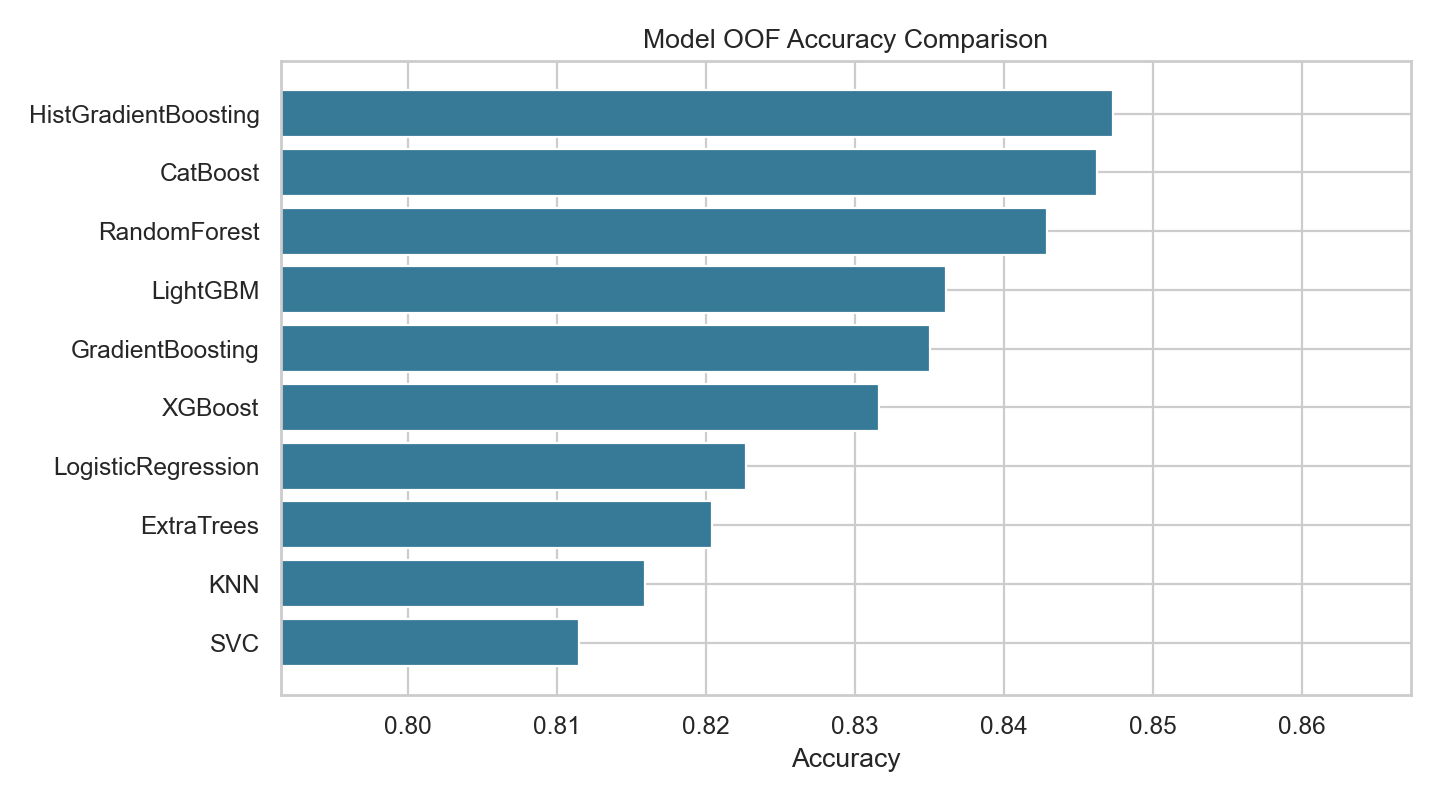

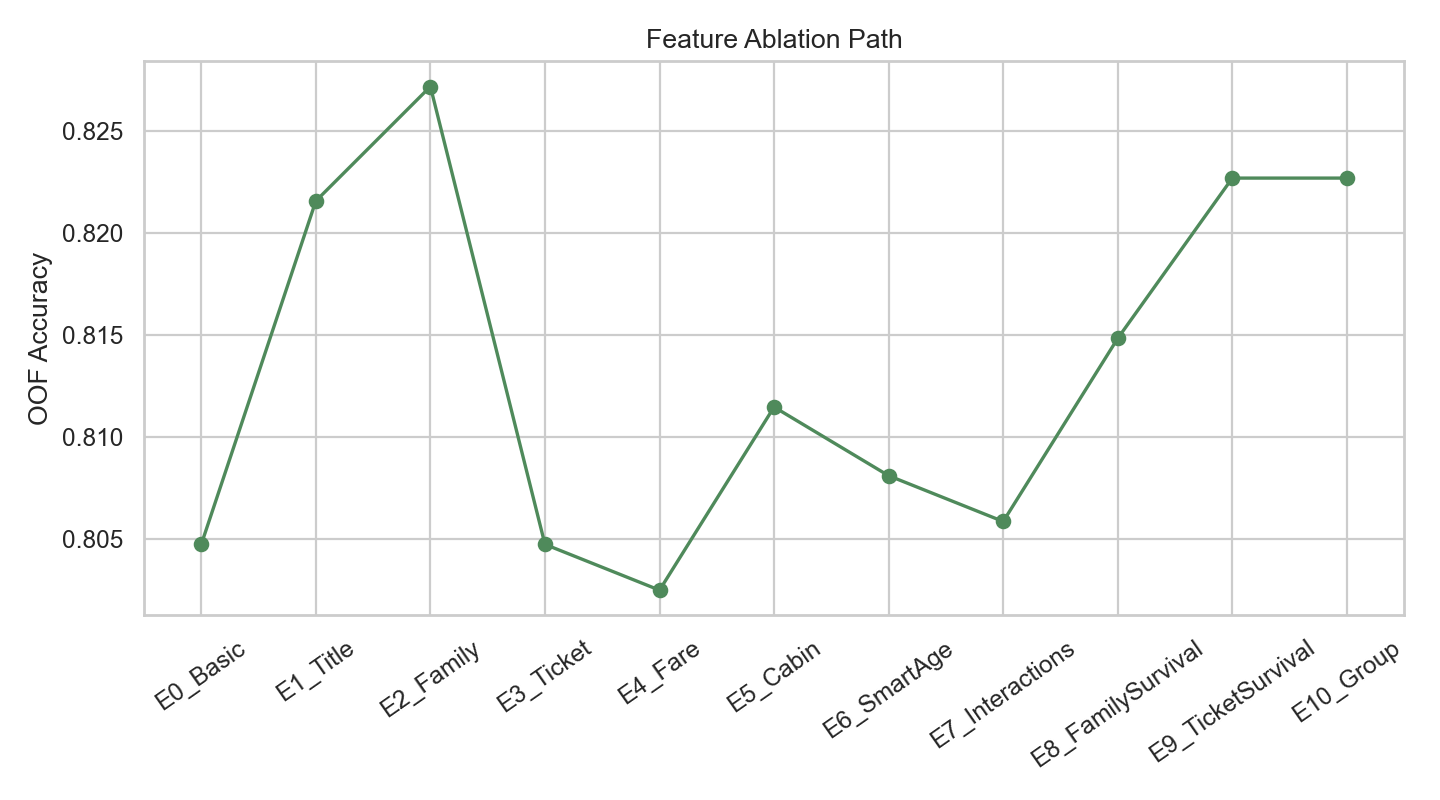

In [4]:
display(Image(filename=str(ROOT/'outputs'/'figures'/'12_model_cv_comparison.png')))
display(Image(filename=str(ROOT/'outputs'/'figures'/'13_feature_ablation_curve.png')))

## Final submission candidates

In [5]:
pd.read_csv(ROOT/'outputs'/'tables'/'submission_disagreement.csv')

,Unnamed: 0,submission_01_best_single,submission_02_weighted_ensemble,submission_03_stacking,submission_04_wcg,submission_05_hybrid
0,submission_01_best_single,0.0,4.0,7.0,38.0,12.0
1,submission_02_weighted_ensemble,4.0,0.0,7.0,42.0,16.0
2,submission_03_stacking,7.0,7.0,0.0,41.0,15.0
3,submission_04_wcg,38.0,42.0,41.0,0.0,26.0
4,submission_05_hybrid,12.0,16.0,15.0,26.0,0.0
